# Automated Computation of Distal Femoral Osteotomy Correction Angles

This project aims to automate the detection of key anatomical landmarks (such as the hip center, distal femur, and ankle center) in long-leg radiographs (X-rays). By accurately locating these components using a YOLO architecture, we can automatically calculate the mechanical axis and the necessary surgical correction angles for a Distal Femoral Osteotomy (DFO).

## Imports

Import standard data handling, computer vision, and deep learning libraries essential for PyTorch and YOLO operations.

In [1]:
import os
import json
import random
import torch
import yaml
from ultralytics import YOLO
import matplotlib.pyplot as plt
from PIL import Image
import matplotlib.patches as patches

## GPU Availability Check

Validating hardware acceleration ensures efficiently trained computer vision models. Here we check the PyTorch version and query the presence and name of any available GPUs.

In [2]:
print(f"PyTorch version: {torch.__version__}")
gpu_available = torch.cuda.is_available()
print(f"GPU available: {gpu_available}")

if gpu_available:
    print(f"GPU Device Name: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.11.0+cu130
GPU available: True
GPU Device Name: NVIDIA GeForce RTX 4070 Laptop GPU


## Data Preparation & Exploratory Data Analysis

Before training our YOLO model, we parse the MS COCO JSON ground truth file to structure the X-ray image data and its YOLO-format label files. We dynamically locate these files, shuffle them to prevent any ordering bias, split them into training, validation, and testing sets, and build the configuration YAML.

### Configuration

Here we define the core paths, target anatomical landmark classes, the desired split ratios across train/val/test, and other global training hyperparameters.

In [3]:
# Configuration Paths & Hyperparameters
DATA_DIR = "/tf/data/hto/xrays"
COCO_JSON_PATH = os.path.join(DATA_DIR, "_annotations_keypoints.coco.json")
CLASSES = ["hip", "distal_femur", "ankle"]
SPLIT_RATIOS = (0.8, 0.1, 0.1)  # 80% Train, 10% Validation, 10% Test

# Model Hyperparameters
OD_EPOCHS = 100
HIP_EPOCHS = 10
IMGSZ = 640
BATCH_SIZE = 16

### Dynamic Dataset Splitting & COCO to YOLO Conversion

We load the MS COCO JSON file containing object annotations (bounding boxes), normalize the coordinates into YOLO format (`x_center, y_center, width, height`), perform a randomized shuffle, and generate the required train/val/test text files which are then indexed in the `data.yaml`.

In [4]:
def prepare_dataset(data_dir, coco_json_path, output_dir="yolo_data"):
    """Converts MS COCO JSON annotations to YOLO format, shuffles images, and creates train/val/test splits."""
    os.makedirs(output_dir, exist_ok=True)
    
    if not os.path.exists(coco_json_path) or not os.path.exists(data_dir):
        print("Warning: Data directory or COCO JSON does not exist. Generating dummy data for dry run...")
        # Create a dummy COCO JSON structure in memory
        dummy_coco = {
            "images": [{"id": i, "file_name": f"sample_{i}.jpg", "width": 1000, "height": 1000} for i in range(100)],
            "annotations": [{"image_id": i, "category_id": random.randint(1, 3), "bbox": [200, 300, 100, 150], "id": i} for i in range(100)],
            "categories": [{"id": 1, "name": "hip"}, {"id": 2, "name": "distal_femur"}, {"id": 3, "name": "ankle"}]
        }
        coco_data = dummy_coco
    else:
        with open(coco_json_path, "r") as f:
            coco_data = json.load(f)
            
    # Create category mapping
    cat_id_to_name = {cat["id"]: cat["name"] for cat in coco_data.get("categories", [])}
    name_to_yolo_id = {name: idx for idx, name in enumerate(CLASSES)}
    
    # Map image IDs to their info and annotations
    images_info = {img["id"]: img for img in coco_data.get("images", [])}
    annotations_by_img = {img_id: [] for img_id in images_info}
    
    for ann in coco_data.get("annotations", []):
        img_id = ann.get("image_id")
        if img_id in annotations_by_img:
            annotations_by_img[img_id].append(ann)
            
    valid_images = list(images_info.keys())
    if not valid_images:
        raise ValueError("No images found in the COCO JSON file.")
        
    # Randomly shuffle images
    random.shuffle(valid_images)
    
    # Calculate split boundaries
    num_imgs = len(valid_images)
    train_end = int(num_imgs * SPLIT_RATIOS[0])
    val_end = train_end + int(num_imgs * SPLIT_RATIOS[1])
    
    splits = {
        "train": valid_images[:train_end],
        "val": valid_images[train_end:val_end],
        "test": valid_images[val_end:]
    }
    
    split_files = {}
    for split_name, img_ids in splits.items():
        images_split_dir = os.path.join(output_dir, "images", split_name)
        labels_split_dir = os.path.join(output_dir, "labels", split_name)
        os.makedirs(images_split_dir, exist_ok=True)
        os.makedirs(labels_split_dir, exist_ok=True)
        
        split_img_paths = []
        for img_id in img_ids:
            img_info = images_info[img_id]
            img_filename = img_info["file_name"]
            src_path = os.path.join(data_dir, img_filename)
            dst_img_path = os.path.join(images_split_dir, os.path.basename(img_filename))
            
            # Either symlink/copy the image or create a dummy file if dry run
            if os.path.exists(src_path):
                if not os.path.exists(dst_img_path):
                    os.symlink(src_path, dst_img_path)
            else:
                # Create dummy file for dry run
                open(dst_img_path, "w").close()
                
            # Convert annotations and write YOLO txt file
            # COCO bbox: [x_min, y_min, width, height]
            txt_filename = os.path.splitext(os.path.basename(img_filename))[0] + ".txt"
            txt_path = os.path.join(labels_split_dir, txt_filename)
            
            with open(txt_path, "w") as f:
                img_w = img_info.get("width", 1000)
                img_h = img_info.get("height", 1000)
                for ann in annotations_by_img[img_id]:
                    bbox = ann.get("bbox", [0, 0, 0, 0])
                    cat_id = ann.get("category_id")
                    cat_name = cat_id_to_name.get(cat_id)
                    if cat_name in name_to_yolo_id:
                        yolo_idx = name_to_yolo_id[cat_name]
                        # Convert to normalized center format
                        x_center = (bbox[0] + bbox[2] / 2.0) / img_w
                        y_center = (bbox[1] + bbox[3] / 2.0) / img_h
                        width = bbox[2] / img_w
                        height = bbox[3] / img_h
                        f.write(f"{yolo_idx} {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}\n")
            
            split_img_paths.append(os.path.abspath(dst_img_path))
            
        file_path = os.path.abspath(os.path.join(output_dir, f"{split_name}.txt"))
        with open(file_path, "w") as f:
            f.write("\n".join(split_img_paths))
        split_files[split_name] = file_path
        
    # Write the data.yaml for YOLO use
    yaml_data = {
        "train": split_files["train"],
        "val": split_files["val"],
        "test": split_files["test"],
        "nc": len(CLASSES),
        "names": CLASSES
    }
    
    yaml_path = os.path.abspath(os.path.join(output_dir, "data.yaml"))
    with open(yaml_path, "w") as f:
        yaml.dump(yaml_data, f, default_flow_style=False)
        
    return yaml_path

data_yaml_path = prepare_dataset(DATA_DIR, COCO_JSON_PATH)
print(f"Dataset configuration written to: {data_yaml_path}")

Dataset configuration written to: /tf/notebooks/yolo_data/data.yaml


### Sanity Check Visualization

Before running our expensive training process, we load and visualize 3-5 randomly chosen images and overlay their associated bounding boxes and labels. This confirms the spatial alignment of annotations.

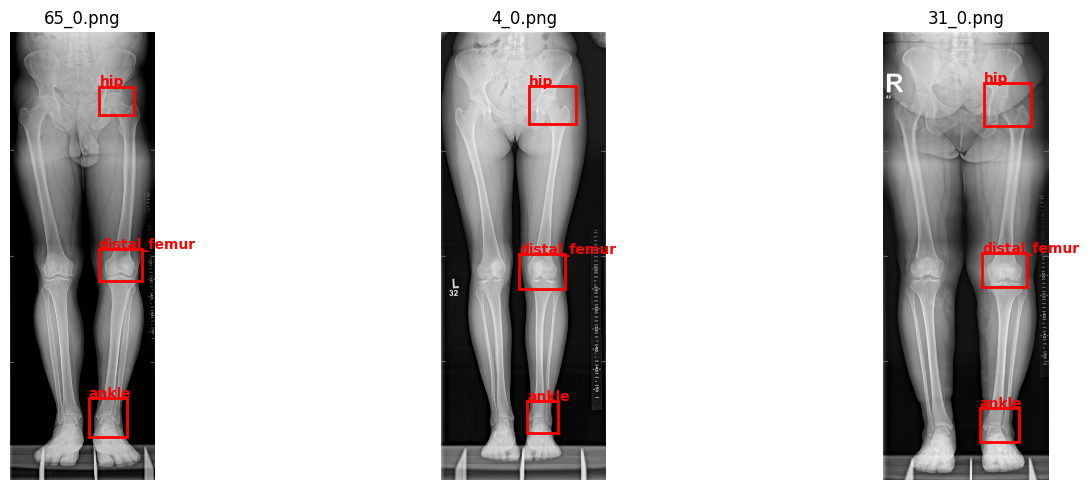

In [5]:
def show_random_samples(data_yaml, num_samples=3):
    with open(data_yaml, "r") as f:
        config = yaml.safe_load(f)
    
    with open(config["train"], "r") as f:
        images = f.read().splitlines()
        
    if not images:
        print("No images found to visualize.")
        return
        
    selected = random.sample(images, min(num_samples, len(images)))
    
    fig, axes = plt.subplots(1, len(selected), figsize=(15, 5))
    if len(selected) == 1:
        axes = [axes]
        
    for idx, img_path in enumerate(selected):
        ax = axes[idx]
        try:
            img = Image.open(img_path)
            ax.imshow(img, cmap="gray")
            w, h = img.size
            
            # Look for matching label file
            label_file = img_path.replace(os.path.join("images", ""), os.path.join("labels", "")).rsplit(".", 1)[0] + ".txt"
            if os.path.exists(label_file):
                with open(label_file, "r") as f:
                    for line in f:
                        parts = line.strip().split()
                        if len(parts) >= 5:
                            cls_id = int(parts[0])
                            x_center, y_center, box_w, box_h = map(float, parts[1:5])
                            xmin = (x_center - box_w / 2) * w
                            ymin = (y_center - box_h / 2) * h
                            rect_w = box_w * w
                            rect_h = box_h * h
                            
                            rect = patches.Rectangle((xmin, ymin), rect_w, rect_h, 
                                                     linewidth=2, edgecolor='red', facecolor='none')
                            ax.add_patch(rect)
                            label = config["names"][cls_id] if cls_id < len(config["names"]) else str(cls_id)
                            ax.text(xmin, ymin - 5, label, color='red', weight='bold')
        except Exception as e:
            ax.set_title(f"Error loading {os.path.basename(img_path)}")
            continue
            
        ax.axis("off")
        ax.set_title(os.path.basename(img_path))
        
    plt.tight_layout()
    plt.show()

# Display the sanity check
if os.path.exists(DATA_DIR):
    show_random_samples(data_yaml_path, num_samples=3)
else:
    print("Data directory not found; skipping sanity check visualization in dry run.")

## Part 1: Regions of Interests Detection

### Model Initialization & Training

We instantiate the YOLO architecture and conduct the optimization process over our processed anatomical dataset.

#### Load Model

We load the lightweight pretrained YOLO26 architecture to warm-start our feature extractors.

In [6]:
print("Loading YOLO26 pretrained weights...")
model = YOLO("yolo26n.pt")

Loading YOLO26 pretrained weights...


#### Training Loop

Execute the primary training routine using our configuration YAML and predefined hyperparameters. YOLO handles optimization, checkpointing, and metric validation internally.

In [7]:
print("Starting YOLO training loop...")
results = model.train(
    data=data_yaml_path,
    epochs=OD_EPOCHS,
    imgsz=IMGSZ,
    batch=BATCH_SIZE,
    device=0,
    
    # Customizing augmentations for Medical Radiographs
    fliplr=0.5,    # Allow horizontal flips (left/right leg symmetry)
    flipud=0.0,    # Prevent upside-down hips/ankles
    degrees=5.0,   # Limit rotation to gentle patient tilts
    scale=0.1,     # Minor zoom-in/out scaling
    mosaic=1.0     # Keep mosaic active for small features
)
print("Training complete!")

Starting YOLO training loop...
New https://pypi.org/project/ultralytics/8.4.43 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.41 🚀 Python-3.11.15 torch-2.11.0+cu130 CUDA:0 (NVIDIA GeForce RTX 4070 Laptop GPU, 8188MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/tf/notebooks/yolo_data/data.yaml, degrees=5.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo2

#### Training Progress

Visualize the resulting optimization progression by plotting both training and validation loss alongside the mean Average Precision (mAP) scores over time.

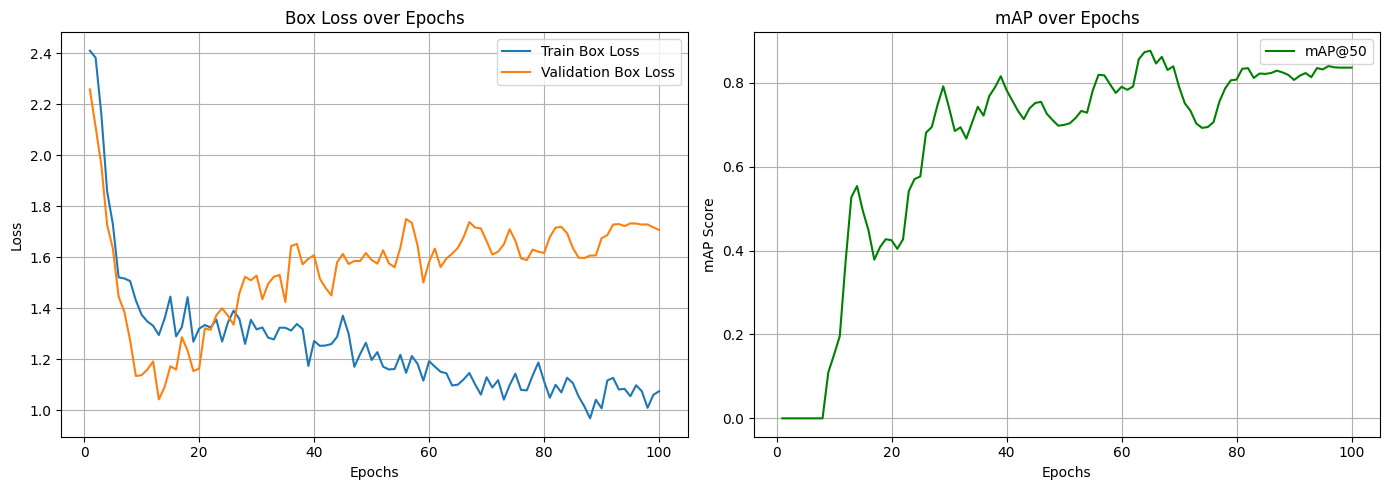

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# Ultralytics typically outputs runs/detect/train/results.csv
results_path = os.path.join("runs", "detect", "train", "results.csv")

if os.path.exists(results_path):
    df = pd.read_csv(results_path)
    df.columns = df.columns.str.strip()
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot Training and Validation Loss
    if "train/box_loss" in df.columns and "val/box_loss" in df.columns:
        ax1.plot(df["epoch"], df["train/box_loss"], label="Train Box Loss")
        ax1.plot(df["epoch"], df["val/box_loss"], label="Validation Box Loss")
        ax1.set_xlabel("Epochs")
        ax1.set_ylabel("Loss")
        ax1.set_title("Box Loss over Epochs")
        ax1.legend()
        ax1.grid(True)
        
    # Plot mAP over time
    map_col = [col for col in df.columns if "mAP50" in col]
    if map_col:
        ax2.plot(df["epoch"], df[map_col[0]], label="mAP@50", color="green")
        ax2.set_xlabel("Epochs")
        ax2.set_ylabel("mAP Score")
        ax2.set_title("mAP over Epochs")
        ax2.legend()
        ax2.grid(True)
        
    plt.tight_layout()
    plt.show()
else:
    print("Results CSV not found; check YOLO output run path. (Expected during dry runs or before training completes)")

### Evaluation & Inference

After training concludes, it is critical to evaluate our model's boundary box positioning and anatomical landmark identification on previously unseen test data.

#### Test Set Inference

Run validation metrics strictly over the held-out test split to ensure the model generalizes cleanly to new patient X-rays.

In [9]:
print("Running model validation on the test split...")
test_metrics = model.val(data=data_yaml_path, split="test")
print(f"Test Set mAP50: {test_metrics.box.map50:.4f}")
print(f"Test Set mAP50-95: {test_metrics.box.map:.4f}")

Running model validation on the test split...
Ultralytics 8.4.41 🚀 Python-3.11.15 torch-2.11.0+cu130 CUDA:0 (NVIDIA GeForce RTX 4070 Laptop GPU, 8188MiB)
YOLO26n summary (fused): 122 layers, 2,375,421 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access ✅ (ping: 3.7±0.3 ms, read: 103.0±4.1 MB/s, size: 7408.2 KB)
val: Scanning /tf/notebooks/yolo_data/labels/test... 7 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 7/7 34.1it/s 0.2s.9s
val: New cache created: /tf/notebooks/yolo_data/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 2.6s/it 2.6s
                   all          7         21      0.628      0.742      0.767      0.381
                   hip          7          7      0.508      0.429      0.604      0.265
          distal_femur          7          7      0.757      0.857      0.855       0.46
                 ankle          7          7      0.621       0.94      0.842      0.419
Speed

#### Testing Metrics

Display standard PR curves, F1-score curves, and confusion matrix heatmaps generated during the testing stage.

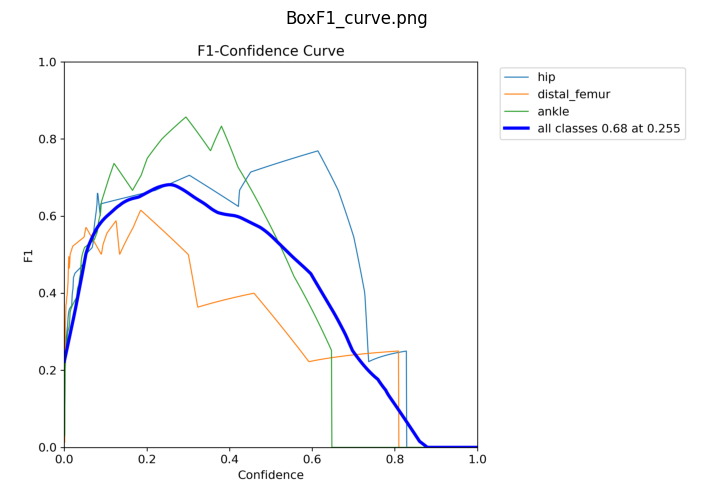

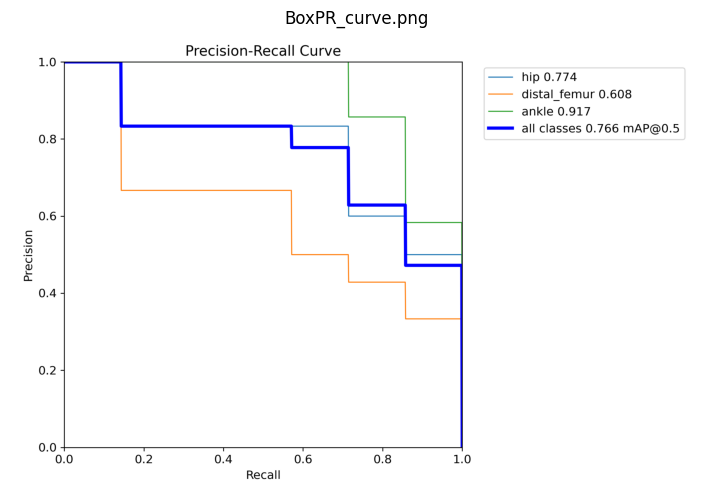

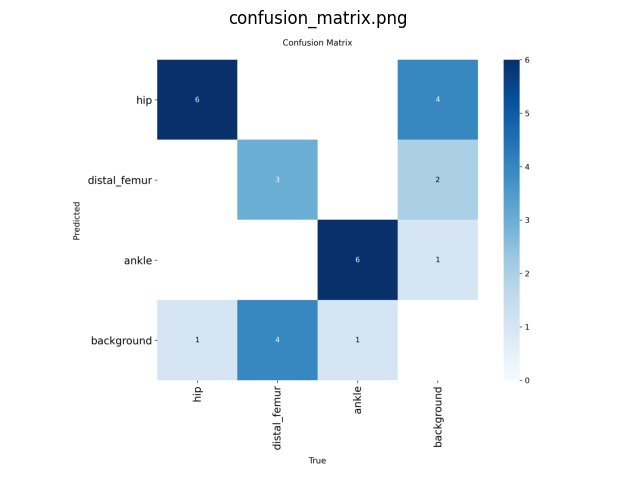

In [10]:
val_dir = os.path.join("runs", "detect", "val")
metric_plots = ["BoxF1_curve.png", "BoxPR_curve.png", "confusion_matrix.png"]

for plot_name in metric_plots:
    plot_path = os.path.join(val_dir, plot_name)
    if os.path.exists(plot_path):
        plt.figure(figsize=(10, 6))
        img = Image.open(plot_path)
        plt.imshow(img)
        plt.axis("off")
        plt.title(plot_name)
        plt.show()
    else:
        print(f"{plot_name} not found in {val_dir} (Available after evaluation)")

#### Result Inspection

Load and visualize raw prediction overlays alongside ground truth boxes on the test dataset so clinicians or engineers can spot correctable alignment errors or edge cases.

Running inference on test sample: /tf/notebooks/yolo_data/images/test/22_0.png

image 1/1 /tf/notebooks/yolo_data/images/test/22_0.png: 640x256 1 distal_femur, 1 ankle, 77.9ms
Speed: 3.0ms preprocess, 77.9ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 256)


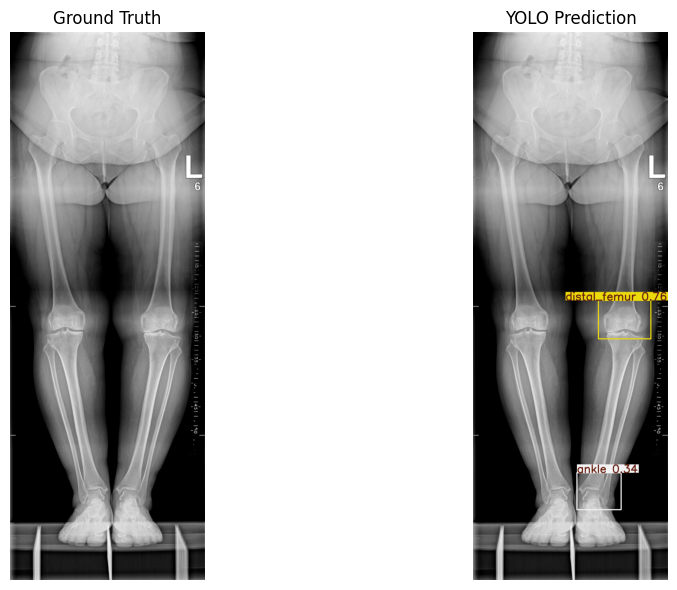

In [11]:
# Read test image paths
with open(os.path.join("yolo_data", "test.txt"), "r") as f:
    test_images = f.read().splitlines()

if test_images:
    sample_img = random.choice(test_images)
    print(f"Running inference on test sample: {sample_img}")
    
    # Run model prediction
    pred = model(sample_img)
    
    # Display results side-by-side
    fig, (ax_gt, ax_pred) = plt.subplots(1, 2, figsize=(12, 6))
    
    # Ground truth display
    img_pil = Image.open(sample_img)
    ax_gt.imshow(img_pil, cmap="gray")
    ax_gt.set_title("Ground Truth")
    ax_gt.axis("off")
    
    # Predicted rendering using ultralytics native plotting
    res_plotted = pred[0].plot()
    ax_pred.imshow(res_plotted)
    ax_pred.set_title("YOLO Prediction")
    ax_pred.axis("off")
    
    plt.tight_layout()
    plt.show()
else:
    print("No test images found.")

## Part 2: Hip Keypoint Detection

In this stage, we crop the detected hip region using letterbox resizing (to preserve original anatomical aspect ratios) and train a Conformer-based keypoint detector to locate the femoral head center (`fem_head_c`).

In [12]:
import math
import numpy as np
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
import torch.nn.functional as F

# Ensure CKD path is accessible
import sys
sys.path.append(os.path.abspath("CKD"))

from models import Conformer_tiny_patch16_keypoint
from utils import extract_coordinates


/tf/notebooks/CKD/vision_transformer.py:370: UserWarning: Overwriting vit_small_patch16_224 in registry with vision_transformer.vit_small_patch16_224. This is because the name being registered conflicts with an existing name. Please check if this is not expected.
  @register_model
/tf/notebooks/CKD/vision_transformer.py:383: UserWarning: Overwriting vit_base_patch16_224 in registry with vision_transformer.vit_base_patch16_224. This is because the name being registered conflicts with an existing name. Please check if this is not expected.
  @register_model
/tf/notebooks/CKD/vision_transformer.py:393: UserWarning: Overwriting vit_base_patch32_224 in registry with vision_transformer.vit_base_patch32_224. This is because the name being registered conflicts with an existing name. Please check if this is not expected.
  @register_model
/tf/notebooks/CKD/vision_transformer.py:402: UserWarning: Overwriting vit_base_patch16_384 in registry with vision_transformer.vit_base_patch16_384. This is b

### Dataset Implementation with Letterbox Resizing

We implement a custom PyTorch Dataset that reads the train/val/test sets generated during Stage 1 to guarantee data consistency, crops the hip bounding box, applies letterbox padding, and builds 2D Gaussian heatmaps for the keypoint (`fem_head_c`) learning objective.

In [13]:
class HipKeypointDataset(Dataset):
    def __init__(self, split_txt_path, coco_json_path, target_size=224, heatmap_scale=0.25, sigma=2.0):
        super().__init__()
        self.target_size = target_size
        self.heatmap_scale = heatmap_scale
        self.sigma = sigma
        
        # Load valid images from the specified split text file
        with open(split_txt_path, "r") as f:
            valid_paths = f.read().splitlines()
        valid_filenames = {os.path.basename(p) for p in valid_paths}
        
        # Load single unified COCO data containing both bboxes and keypoints
        with open(coco_json_path, "r") as f:
            coco_data = json.load(f)
            
        # Build image ID to filename map
        img_info_map = {img["id"]: img for img in coco_data["images"]}
        
        # Find Category ID for "hip"
        hip_cat_id = next((cat["id"] for cat in coco_data["categories"] if cat["name"] == "hip"), 1)
        
        # Build dataset samples directly from unified annotations
        self.samples = []
        for ann in coco_data["annotations"]:
            img_id = ann["image_id"]
            if img_id in img_info_map:
                filename = img_info_map[img_id]["file_name"]
                if filename in valid_filenames and ann["category_id"] == hip_cat_id and ann.get("keypoints"):
                    self.samples.append({
                        "img_path": os.path.join(os.path.dirname(coco_json_path), filename),
                        "bbox": ann["bbox"],  # [x, y, w, h]
                        "keypoints": ann["keypoints"][:2]  # [x, y]
                    })
                        
    def __len__(self):
        return len(self.samples)
        
    def __getitem__(self, idx):
        sample = self.samples[idx]
        bbox = sample["bbox"]
        kp = sample["keypoints"]
        
        # Load Image and Crop
        img = Image.open(sample["img_path"]).convert("RGB")
        cropped = img.crop((bbox[0], bbox[1], bbox[0] + bbox[2], bbox[1] + bbox[3]))
        
        # Sub-crop adjustments for the keypoint
        kp_rel_x = kp[0] - bbox[0]
        kp_rel_y = kp[1] - bbox[1]
        
        # Letterbox Resizing to preserve aspect ratio
        orig_w, orig_h = cropped.size
        scale = min(self.target_size / orig_w, self.target_size / orig_h)
        
        new_w = int(orig_w * scale)
        new_h = int(orig_h * scale)
        
        resized = cropped.resize((new_w, new_h), Image.Resampling.LANCZOS)
        
        pad_left = (self.target_size - new_w) // 2
        pad_top = (self.target_size - new_h) // 2
        
        final_img = Image.new("RGB", (self.target_size, self.target_size), (0, 0, 0))
        final_img.paste(resized, (pad_left, pad_top))
        
        # Adjusted keypoint coordinates mapped into the letterbox space
        kp_final_x = kp_rel_x * scale + pad_left
        kp_final_y = kp_rel_y * scale + pad_top
        
        # Convert image to PyTorch tensor
        img_tensor = torch.from_numpy(np.array(final_img)).permute(2, 0, 1).float() / 255.0
        
        # Generate 2D Gaussian Heatmap for the target
        hm_size = int(self.target_size * self.heatmap_scale)
        heatmap = np.zeros((1, hm_size, hm_size), dtype=np.float32)
        
        kp_hm_x = kp_final_x * self.heatmap_scale
        kp_hm_y = kp_final_y * self.heatmap_scale
        
        # Generate the Gaussian distribution
        x_grid = np.arange(0, hm_size, 1, np.float32)
        y_grid = np.arange(0, hm_size, 1, np.float32)[:, np.newaxis]
        
        heatmap[0] = np.exp(-((x_grid - kp_hm_x)**2 + (y_grid - kp_hm_y)**2) / (2 * self.sigma**2))
        
        return {
            "image": img_tensor,
            "heatmap": torch.from_numpy(heatmap),
            "keypoint": torch.tensor([kp_final_x, kp_final_y], dtype=torch.float32),
            "img_path": sample["img_path"]
        }


### Model Initialization & Hyperparameters

Instantiate the Conformer architecture wrapper expecting a single keypoint target (`fem_head_c`).

In [14]:
KP_COCO_PATH = os.path.join(DATA_DIR, "_annotations_keypoints.coco.json")

if os.path.exists(KP_COCO_PATH):
    train_ds = HipKeypointDataset(os.path.join("yolo_data", "train.txt"), KP_COCO_PATH)
    val_ds = HipKeypointDataset(os.path.join("yolo_data", "val.txt"), KP_COCO_PATH)
    test_ds = HipKeypointDataset(os.path.join("yolo_data", "test.txt"), KP_COCO_PATH)

    if len(train_ds) > 0:
        train_loader = DataLoader(train_ds, batch_size=8, shuffle=True)
    if len(val_ds) > 0:
        val_loader = DataLoader(val_ds, batch_size=8, shuffle=False)
    if len(test_ds) > 0:
        test_loader = DataLoader(test_ds, batch_size=8, shuffle=False)
    
    print(f"Stage 2 Dataset loaded! Train size: {len(train_ds)}, Validation size: {len(val_ds)}, Test size: {len(test_ds)}")
else:
    print("Unified Keypoint annotations not found under specified paths; skipping Dataset setup.")


Stage 2 Dataset loaded! Train size: 56, Validation size: 7, Test size: 7


### Model Training & Optimization

Trains the network to minimize Mean Squared Error loss over the predicted spatial heatmaps.

Epoch 1 | Training Loss: 0.125496 | Validation Loss: 0.005639 | Validation NMSE: 0.178925
Epoch 2 | Training Loss: 0.045918 | Validation Loss: 0.004671 | Validation NMSE: 0.351411
Epoch 3 | Training Loss: 0.016140 | Validation Loss: 0.005562 | Validation NMSE: 0.202146
Epoch 4 | Training Loss: 0.008442 | Validation Loss: 0.005937 | Validation NMSE: 0.137748
Epoch 5 | Training Loss: 0.006932 | Validation Loss: 0.005800 | Validation NMSE: 0.355223
Epoch 6 | Training Loss: 0.006037 | Validation Loss: 0.005418 | Validation NMSE: 0.217195
Epoch 7 | Training Loss: 0.005401 | Validation Loss: 0.005130 | Validation NMSE: 0.218389
Epoch 8 | Training Loss: 0.005124 | Validation Loss: 0.004888 | Validation NMSE: 0.329330
Epoch 9 | Training Loss: 0.004954 | Validation Loss: 0.004758 | Validation NMSE: 0.285047
Epoch 10 | Training Loss: 0.004801 | Validation Loss: 0.004736 | Validation NMSE: 0.295108


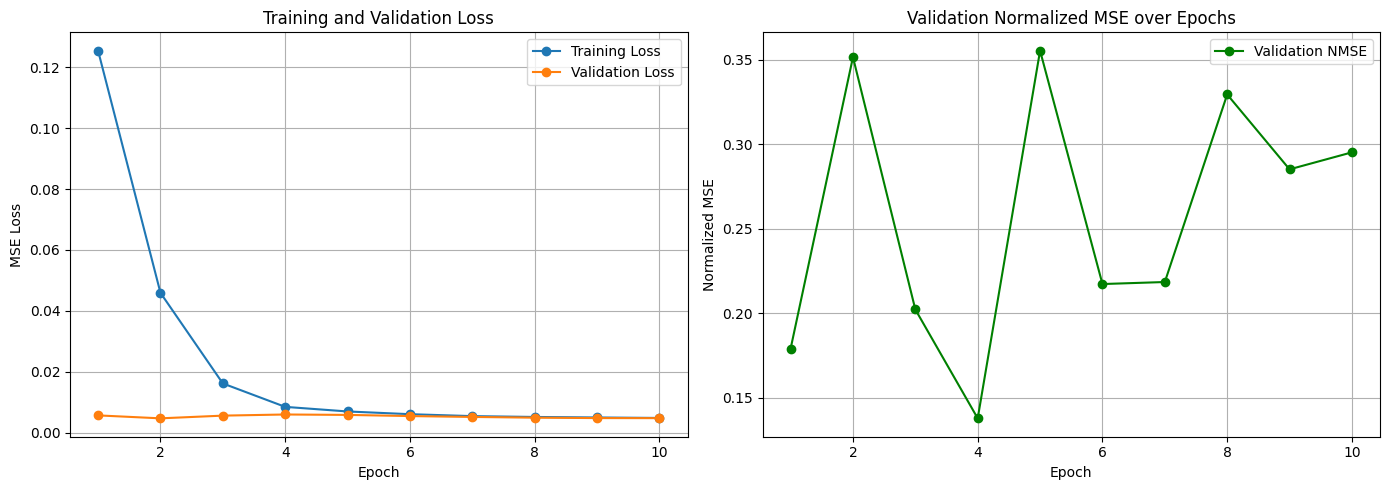

In [15]:
# Instantiate the Conformer Tiny Keypoint model
model_keypoint = Conformer_tiny_patch16_keypoint(num_keypoints=1)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_keypoint.to(device)

optimizer = optim.AdamW(model_keypoint.parameters(), lr=1e-4)
criterion = torch.nn.MSELoss()

train_losses = []
val_losses = []
val_nmses = []

# Execute a robust epoch loop including loss and NMSE tracking
if 'train_loader' in locals() and len(train_ds) > 0:
    for epoch in range(HIP_EPOCHS):
        # Training Phase
        model_keypoint.train()
        epoch_loss = 0.0
        for batch in train_loader:
            imgs = batch["image"].to(device)
            target_hms = batch["heatmap"].to(device)
            
            optimizer.zero_grad()
            pred_hms = model_keypoint(imgs)
            loss = criterion(pred_hms, target_hms)
            
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            
        train_loss = epoch_loss / len(train_loader)
        train_losses.append(train_loss)
        
        # Validation Phase
        val_loss = 0.0
        epoch_preds = []
        epoch_gts = []
        
        if 'val_loader' in locals() and len(val_ds) > 0:
            model_keypoint.eval()
            with torch.no_grad():
                for batch in val_loader:
                    imgs = batch["image"].to(device)
                    target_hms = batch["heatmap"].to(device)
                    target_kps = batch["keypoint"]
                    
                    pred_hms = model_keypoint(imgs)
                    loss = criterion(pred_hms, target_hms)
                    val_loss += loss.item()
                    
                    pred_coords = extract_coordinates(pred_hms.cpu(), scale_factor=4.0).squeeze(1)
                    epoch_preds.append(pred_coords)
                    epoch_gts.append(target_kps)
                    
            val_loss /= len(val_loader)
            val_losses.append(val_loss)
            
            all_preds = torch.cat(epoch_preds, dim=0)
            all_gts = torch.cat(epoch_gts, dim=0)
            
            diff = all_preds - all_gts
            mse = torch.mean(torch.sum(diff ** 2, dim=-1))
            nmse = (mse / (224 ** 2)).item()
            val_nmses.append(nmse)
            
        print(f"Epoch {epoch+1} | Training Loss: {train_loss:.6f} | Validation Loss: {val_loss:.6f} | Validation NMSE: {nmse:.6f}")
        
    # Plotting Training/Validation Loss and NMSE
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    epochs_range = range(1, len(train_losses) + 1)
    
    ax1.plot(epochs_range, train_losses, label="Training Loss", marker='o')
    ax1.plot(epochs_range, val_losses, label="Validation Loss", marker='o')
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("MSE Loss")
    ax1.set_title("Training and Validation Loss")
    ax1.legend()
    ax1.grid(True)
    
    ax2.plot(epochs_range, val_nmses, label="Validation NMSE", color="green", marker='o')
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Normalized MSE")
    ax2.set_title("Validation Normalized MSE over Epochs")
    ax2.legend()
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()
else:
    print("Skipping Conformer training loop and plots due to missing local dataset.")


### Evaluation and Visualization

Extract coordinate pairs from output heatmaps using the supplied `extract_coordinates` utility, compute Normalized MSE, and visualize the ground truth against predictions.

Normalized Mean Squared Error (NMSE) on Test Set: 0.347253


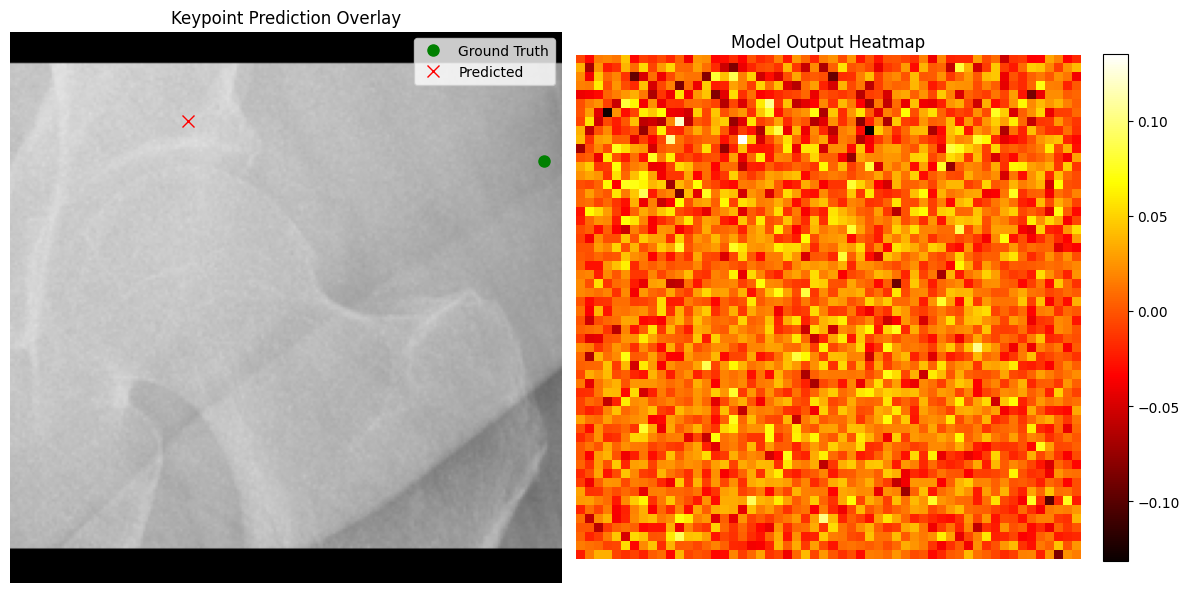

In [16]:
def compute_normalized_mse(preds, targets, image_size=224):
    """Computes MSE normalized by the squared dimensions of the cropped image."""
    diff = preds - targets
    mse = torch.mean(torch.sum(diff ** 2, dim=-1))
    nmse = mse / (image_size ** 2)
    return nmse.item()

if 'test_loader' in locals() and len(test_ds) > 0:
    model_keypoint.eval()
    
    all_preds = []
    all_gts = []
    
    sample_batch = None
    
    with torch.no_grad():
        for batch in test_loader:
            imgs = batch["image"].to(device)
            target_kps = batch["keypoint"]
            
            pred_hms = model_keypoint(imgs)
            
            # Use utility method to extract locations from predicted heatmaps
            pred_coords = extract_coordinates(pred_hms.cpu(), scale_factor=4.0)
            pred_coords = pred_coords.squeeze(1)  # [Batch, 2]
            
            all_preds.append(pred_coords)
            all_gts.append(target_kps)
            
            if sample_batch is None:
                sample_batch = (imgs.cpu(), pred_hms.cpu(), target_kps, pred_coords)
                
    all_preds = torch.cat(all_preds, dim=0)
    all_gts = torch.cat(all_gts, dim=0)
    
    nmse_val = compute_normalized_mse(all_preds, all_gts)
    print(f"Normalized Mean Squared Error (NMSE) on Test Set: {nmse_val:.6f}")
    
    # Visual Verification: Plot Image Overlay alongside Predicted Heatmap
    sample_img, sample_hms, sample_gt, sample_pred = sample_batch
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
    
    # Left Subplot: Image with Bounding Boxes / Keypoint Overlay
    img_show = sample_img[0].permute(1, 2, 0).numpy()
    ax1.imshow(img_show, cmap="gray")
    
    gt_x, gt_y = sample_gt[0].numpy()
    pred_x, pred_y = sample_pred[0].numpy()
    
    ax1.plot(gt_x, gt_y, 'go', markersize=8, label="Ground Truth")
    ax1.plot(pred_x, pred_y, 'rx', markersize=8, label="Predicted")
    ax1.legend()
    ax1.set_title("Keypoint Prediction Overlay")
    ax1.axis("off")
    
    # Right Subplot: Predicted Heatmap
    hm_show = sample_hms[0, 0].numpy()
    im = ax2.imshow(hm_show, cmap='hot', interpolation='nearest')
    ax2.set_title("Model Output Heatmap")
    ax2.axis("off")
    fig.colorbar(im, ax=ax2, fraction=0.046, pad=0.04)
    
    plt.tight_layout()
    plt.show()
else:
    print("Skipping test set inference / visualization (waiting for trained model).")


## Part 3: Distal Femur Keypoint Detection

In this stage, we crop the detected distal femur region using letterbox resizing (to preserve original anatomical aspect ratios) and train a Conformer-based keypoint detector to locate the distal femur keypoints (`knee_joint_c`, `fujisawa`, `hinge`, `start_point`).

### Dataset Implementation with Letterbox Resizing

We implement a custom PyTorch Dataset that reads the train/val/test sets generated during Stage 1 to guarantee data consistency, crops the distal femur bounding box, applies letterbox padding, and builds 2D Gaussian heatmaps for the 4 keypoints (`knee_joint_c`, `fujisawa`, `hinge`, `start_point`) learning objective.

In [17]:
class DistalFemurKeypointDataset(Dataset):
    def __init__(self, split_txt_path, coco_json_path, target_size=224, heatmap_scale=0.25, sigma=2.0):
        super().__init__()
        self.target_size = target_size
        self.heatmap_scale = heatmap_scale
        self.sigma = sigma
        
        # Load valid images from the specified split text file
        with open(split_txt_path, "r") as f:
            valid_paths = f.read().splitlines()
        valid_filenames = {os.path.basename(p) for p in valid_paths}
        
        # Load single unified COCO data containing both bboxes and keypoints
        with open(coco_json_path, "r") as f:
            coco_data = json.load(f)
            
        # Build image ID to filename map
        img_info_map = {img["id"]: img for img in coco_data["images"]}
        
        # Find Category ID for "distal_femur"
        # From COCO: category_id 2 is "distal_femur"
        df_cat_id = next((cat["id"] for cat in coco_data["categories"] if cat["name"] == "distal_femur"), 2)
        
        # Build dataset samples directly from unified annotations
        self.samples = []
        for ann in coco_data["annotations"]:
            img_id = ann["image_id"]
            if img_id in img_info_map:
                filename = img_info_map[img_id]["file_name"]
                if filename in valid_filenames and ann["category_id"] == df_cat_id and ann.get("keypoints"):
                    self.samples.append({
                        "img_path": os.path.join(os.path.dirname(coco_json_path), filename),
                        "bbox": ann["bbox"],  # [x, y, w, h]
                        "keypoints": ann["keypoints"]  # All keypoints
                    })
                        
    def __len__(self):
        return len(self.samples)
        
    def __getitem__(self, idx):
        sample = self.samples[idx]
        bbox = sample["bbox"]
        kps = sample["keypoints"]
        
        # Load Image and Crop
        img = Image.open(sample["img_path"]).convert("RGB")
        cropped = img.crop((bbox[0], bbox[1], bbox[0] + bbox[2], bbox[1] + bbox[3]))
        
        # Letterbox Resizing to preserve aspect ratio
        orig_w, orig_h = cropped.size
        scale = min(self.target_size / orig_w, self.target_size / orig_h)
        
        new_w = int(orig_w * scale)
        new_h = int(orig_h * scale)
        
        resized = cropped.resize((new_w, new_h), Image.Resampling.LANCZOS)
        
        pad_left = (self.target_size - new_w) // 2
        pad_top = (self.target_size - new_h) // 2
        
        final_img = Image.new("RGB", (self.target_size, self.target_size), (0, 0, 0))
        final_img.paste(resized, (pad_left, pad_top))
        
        # Adjusted keypoint coordinates mapped into the letterbox space for 4 keypoints
        # The 4 keypoints are: knee_joint_c, fujisawa, hinge, start_point
        final_kps = []
        for i in range(4):
            kp_x = kps[i * 3]
            kp_y = kps[i * 3 + 1]
            kp_rel_x = kp_x - bbox[0]
            kp_rel_y = kp_y - bbox[1]
            kp_final_x = kp_rel_x * scale + pad_left
            kp_final_y = kp_rel_y * scale + pad_top
            final_kps.append([kp_final_x, kp_final_y])
        
        # Convert image to PyTorch tensor
        img_tensor = torch.from_numpy(np.array(final_img)).permute(2, 0, 1).float() / 255.0
        
        # Generate 2D Gaussian Heatmaps for each target
        hm_size = int(self.target_size * self.heatmap_scale)
        heatmap = np.zeros((4, hm_size, hm_size), dtype=np.float32)
        
        x_grid = np.arange(0, hm_size, 1, np.float32)
        y_grid = np.arange(0, hm_size, 1, np.float32)[:, np.newaxis]
        
        for i in range(4):
            kp_hm_x = final_kps[i][0] * self.heatmap_scale
            kp_hm_y = final_kps[i][1] * self.heatmap_scale
            heatmap[i] = np.exp(-((x_grid - kp_hm_x)**2 + (y_grid - kp_hm_y)**2) / (2 * self.sigma**2))
        
        return {
            "image": img_tensor,
            "heatmap": torch.from_numpy(heatmap),
            "keypoint": torch.tensor(final_kps, dtype=torch.float32),
            "img_path": sample["img_path"]
        }

### Model Initialization & Hyperparameters

Instantiate the Conformer architecture wrapper expecting 4 keypoint targets (`knee_joint_c`, `fujisawa`, `hinge`, `start_point`).

In [18]:
if os.path.exists(KP_COCO_PATH):
    # Using the same KP_COCO_PATH as Part 2
    df_train_ds = DistalFemurKeypointDataset(os.path.join("yolo_data", "train.txt"), KP_COCO_PATH)
    df_val_ds = DistalFemurKeypointDataset(os.path.join("yolo_data", "val.txt"), KP_COCO_PATH)
    df_test_ds = DistalFemurKeypointDataset(os.path.join("yolo_data", "test.txt"), KP_COCO_PATH)

    if len(df_train_ds) > 0:
        df_train_loader = DataLoader(df_train_ds, batch_size=8, shuffle=True)
    if len(df_val_ds) > 0:
        df_val_loader = DataLoader(df_val_ds, batch_size=8, shuffle=False)
    if len(df_test_ds) > 0:
        df_test_loader = DataLoader(df_test_ds, batch_size=8, shuffle=False)
    
    print(f"Stage 3 Dataset loaded! Train size: {len(df_train_ds)}, Validation size: {len(df_val_ds)}, Test size: {len(df_test_ds)}")
else:
    print("Unified Keypoint annotations not found under specified paths; skipping Dataset setup.")

Stage 3 Dataset loaded! Train size: 55, Validation size: 7, Test size: 7


### Model Training & Optimization

Trains the network to minimize Mean Squared Error loss over the predicted spatial heatmaps.

Epoch 1 | Training Loss: 0.128115 | Validation Loss: 0.006065 | Validation NMSE: 0.255160
Epoch 2 | Training Loss: 0.055242 | Validation Loss: 0.008181 | Validation NMSE: 0.345337
Epoch 3 | Training Loss: 0.025657 | Validation Loss: 0.009767 | Validation NMSE: 0.359056
Epoch 4 | Training Loss: 0.013171 | Validation Loss: 0.009482 | Validation NMSE: 0.359717
Epoch 5 | Training Loss: 0.008152 | Validation Loss: 0.007762 | Validation NMSE: 0.281143
Epoch 6 | Training Loss: 0.006067 | Validation Loss: 0.006105 | Validation NMSE: 0.332649
Epoch 7 | Training Loss: 0.005222 | Validation Loss: 0.005225 | Validation NMSE: 0.310005
Epoch 8 | Training Loss: 0.004863 | Validation Loss: 0.004697 | Validation NMSE: 0.376409
Epoch 9 | Training Loss: 0.004663 | Validation Loss: 0.004451 | Validation NMSE: 0.344075
Epoch 10 | Training Loss: 0.004549 | Validation Loss: 0.004380 | Validation NMSE: 0.345763


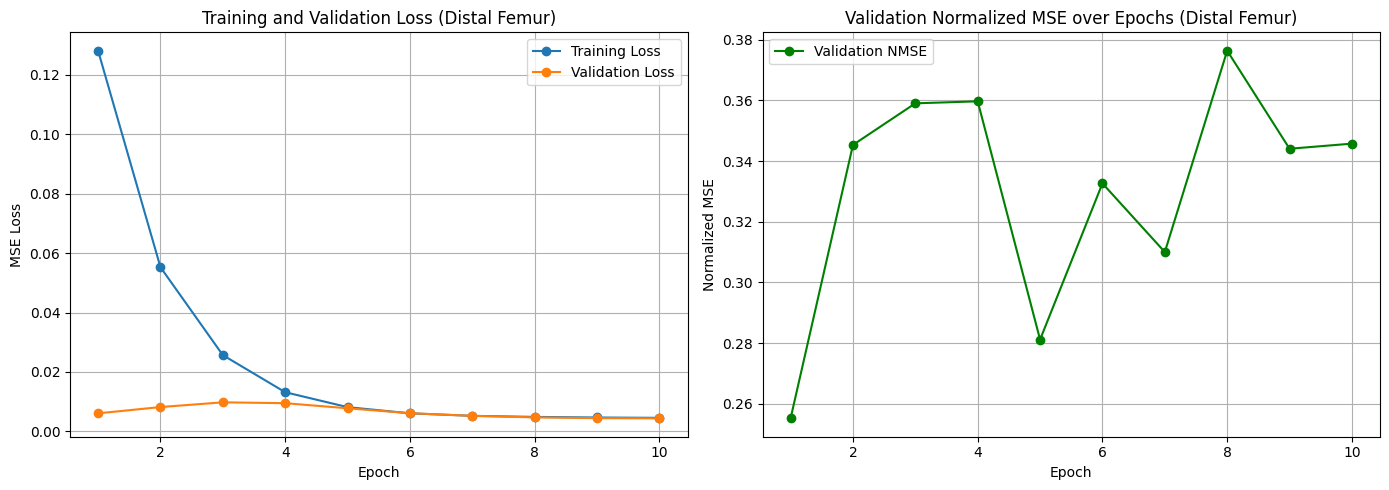

In [19]:
# Instantiate the Conformer Tiny Keypoint model with 4 keypoints
df_model_keypoint = Conformer_tiny_patch16_keypoint(num_keypoints=4)
df_model_keypoint.to(device)

df_optimizer = optim.AdamW(df_model_keypoint.parameters(), lr=1e-4)
# device and criterion are already defined in Part 2

df_train_losses = []
df_val_losses = []
df_val_nmses = []

if 'df_train_loader' in locals() and len(df_train_ds) > 0:
    for epoch in range(HIP_EPOCHS):
        # Training Phase
        df_model_keypoint.train()
        epoch_loss = 0.0
        for batch in df_train_loader:
            imgs = batch["image"].to(device)
            target_hms = batch["heatmap"].to(device)
            
            df_optimizer.zero_grad()
            pred_hms = df_model_keypoint(imgs)
            loss = criterion(pred_hms, target_hms)
            
            loss.backward()
            df_optimizer.step()
            epoch_loss += loss.item()
            
        train_loss = epoch_loss / len(df_train_loader)
        df_train_losses.append(train_loss)
        
        # Validation Phase
        val_loss = 0.0
        epoch_preds = []
        epoch_gts = []
        
        if 'df_val_loader' in locals() and len(df_val_ds) > 0:
            df_model_keypoint.eval()
            with torch.no_grad():
                for batch in df_val_loader:
                    imgs = batch["image"].to(device)
                    target_hms = batch["heatmap"].to(device)
                    target_kps = batch["keypoint"]
                    
                    pred_hms = df_model_keypoint(imgs)
                    loss = criterion(pred_hms, target_hms)
                    val_loss += loss.item()
                    
                    # Extract coordinates from predicted heatmaps
                    pred_coords = extract_coordinates(pred_hms.cpu(), scale_factor=4.0)
                    epoch_preds.append(pred_coords)
                    epoch_gts.append(target_kps)
                    
            val_loss /= len(df_val_loader)
            df_val_losses.append(val_loss)
            
            all_preds = torch.cat(epoch_preds, dim=0)
            all_gts = torch.cat(epoch_gts, dim=0)
            
            # Compute Normalized MSE
            diff = all_preds - all_gts
            mse = torch.mean(torch.sum(diff ** 2, dim=-1))
            nmse = (mse / (224 ** 2)).item()
            df_val_nmses.append(nmse)
            
        print(f"Epoch {epoch+1} | Training Loss: {train_loss:.6f} | Validation Loss: {val_loss:.6f} | Validation NMSE: {nmse:.6f}")
        
    # Plotting Training/Validation Loss and NMSE
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    epochs_range = range(1, len(df_train_losses) + 1)
    
    ax1.plot(epochs_range, df_train_losses, label="Training Loss", marker='o')
    ax1.plot(epochs_range, df_val_losses, label="Validation Loss", marker='o')
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("MSE Loss")
    ax1.set_title("Training and Validation Loss (Distal Femur)")
    ax1.legend()
    ax1.grid(True)
    
    ax2.plot(epochs_range, df_val_nmses, label="Validation NMSE", color="green", marker='o')
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Normalized MSE")
    ax2.set_title("Validation Normalized MSE over Epochs (Distal Femur)")
    ax2.legend()
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()
else:
    print("Skipping Conformer training loop and plots due to missing local dataset.")

### Evaluation and Visualization

Extract coordinate pairs from output heatmaps, compute Normalized MSE, and visualize the ground truth against predictions for the distal femur keypoints.

Normalized Mean Squared Error (NMSE) on Test Set: 0.384347


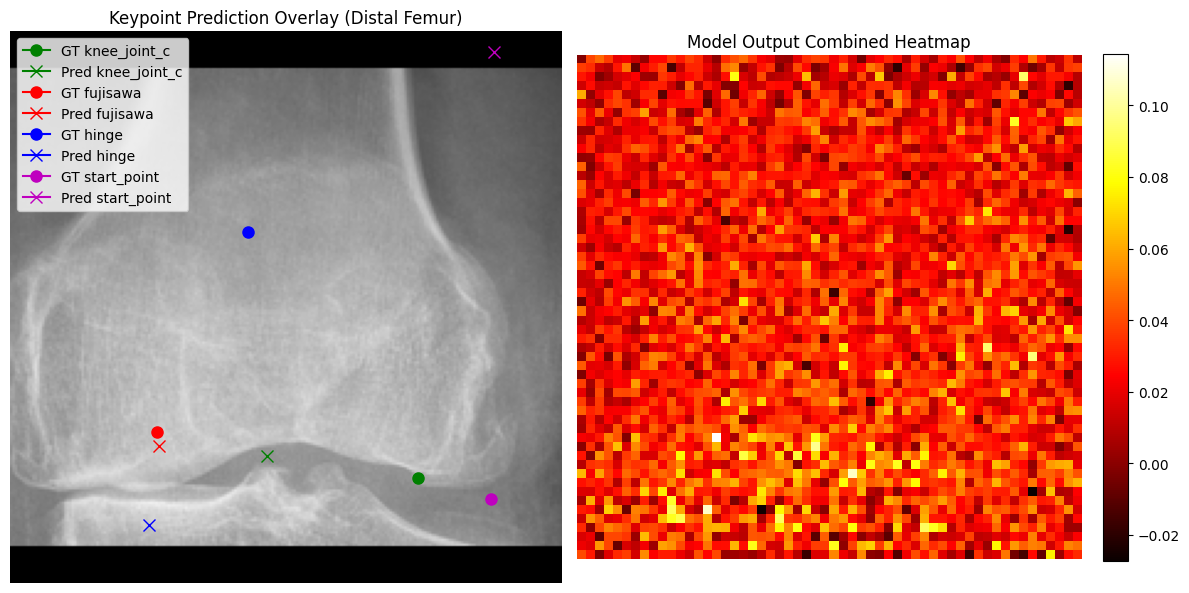

In [20]:
if 'df_test_loader' in locals() and len(df_test_ds) > 0:
    df_model_keypoint.eval()
    
    all_preds = []
    all_gts = []
    
    sample_batch = None
    
    with torch.no_grad():
        for batch in df_test_loader:
            imgs = batch["image"].to(device)
            target_kps = batch["keypoint"]
            
            pred_hms = df_model_keypoint(imgs)
            
            pred_coords = extract_coordinates(pred_hms.cpu(), scale_factor=4.0)
            
            all_preds.append(pred_coords)
            all_gts.append(target_kps)
            
            if sample_batch is None:
                sample_batch = (imgs.cpu(), pred_hms.cpu(), target_kps, pred_coords)
                
    all_preds = torch.cat(all_preds, dim=0)
    all_gts = torch.cat(all_gts, dim=0)
    
    nmse_val = compute_normalized_mse(all_preds, all_gts)
    print(f"Normalized Mean Squared Error (NMSE) on Test Set: {nmse_val:.6f}")
    
    sample_img, sample_hms, sample_gt, sample_pred = sample_batch
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
    
    img_show = sample_img[0].permute(1, 2, 0).numpy()
    ax1.imshow(img_show, cmap="gray")
    
    labels = ["knee_joint_c", "fujisawa", "hinge", "start_point"]
    colors = ["g", "r", "b", "m"]
    
    for i in range(4):
        gt_x, gt_y = sample_gt[0, i].numpy()
        pred_x, pred_y = sample_pred[0, i].numpy()
        
        ax1.plot(gt_x, gt_y, marker='o', color=colors[i], markersize=8, label=f"GT {labels[i]}")
        ax1.plot(pred_x, pred_y, marker='x', color=colors[i], markersize=8, label=f"Pred {labels[i]}")
        
    ax1.legend()
    ax1.set_title("Keypoint Prediction Overlay (Distal Femur)")
    ax1.axis("off")
    
    # Show the combined heatmap (max across channels)
    hm_show = torch.max(sample_hms[0], dim=0)[0].numpy()
    im = ax2.imshow(hm_show, cmap='hot', interpolation='nearest')
    ax2.set_title("Model Output Combined Heatmap")
    ax2.axis("off")
    fig.colorbar(im, ax=ax2, fraction=0.046, pad=0.04)
    
    plt.tight_layout()
    plt.show()
else:
    print("Skipping test set inference / visualization (waiting for trained model).")